# Dependencies:

In [2]:
pip install faker prettytable matplotlib pandas numpy statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.9 MB/s eta 0:00:00


In [3]:
from faker import Faker
import sqlite3
import random
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt

# Faker's initialization and table schemas:



In [4]:

fake = Faker('pt_BR')

def connect():
    return sqlite3.connect('ecommerce_analytics.db')

def create_schema():
    sql = """
    PRAGMA foreign_keys = ON;

    CREATE TABLE IF NOT EXISTS Customers(
        CustomerID INTEGER PRIMARY KEY,
        CustomerName TEXT NOT NULL,
        CustomerAge INTEGER NOT NULL,
        City TEXT
    );

    CREATE TABLE IF NOT EXISTS Categories(
        CategoryID INTEGER PRIMARY KEY,
        CategoryName TEXT NOT NULL
    );

    CREATE TABLE IF NOT EXISTS Orders(
        OrderID INTEGER PRIMARY KEY,
        CustomerID INTEGER,
        CategoryID INTEGER,
        OrderValue REAL NOT NULL,
        OrderDate DATE NOT NULL,
        FOREIGN KEY(CustomerID) REFERENCES Customers(CustomerID),
        FOREIGN KEY(CategoryID) REFERENCES Categories(CategoryID)
    );
    """
    conn = connect()
    cursor = conn.cursor()
    cursor.executescript(sql)
    conn.commit()
    conn.close()

# Seeding:

In [5]:
def seed_data():
    conn = connect()
    cursor = conn.cursor()

    num_customers = 10000  # Adjust if needed
    customers = [(fake.name(), random.randint(18, 80), fake.city()) for _ in range(num_customers)]
    cursor.executemany('INSERT INTO Customers(CustomerName, CustomerAge, City) VALUES (?, ?, ?)', customers)

    categories = ["Eletrônicos", "Moda", "Alimentos", "Casa", "Livros"]
    cursor.executemany('INSERT INTO Categories(CategoryName) VALUES (?)', [(c,) for c in categories])

    cursor.execute("SELECT CategoryID FROM Categories")
    cat_ids = [row[0] for row in cursor.fetchall()]

    orders = []
    for customer_id in range(1, num_customers + 1):
        for _ in range(random.randint(1, 10)):
            cat_id = random.choice(cat_ids)
            val = round(random.uniform(20.0, 5000.0), 2)
            date = fake.date_between(start_date='-2y', end_date='today')
            orders.append((customer_id, cat_id, val, date))

    cursor.executemany('INSERT INTO Orders (CustomerID, CategoryID, OrderValue, OrderDate) VALUES (?, ?, ?, ?)', orders)
    conn.commit()
    conn.close()

# Exec:

In [6]:
create_schema()
seed_data()

/tmp/ipykernel_1047/1079386942.py:23: DeprecationWarning: The default date adapter is deprecated as of Python 3.12; see the sqlite3 documentation for suggested replacement recipes
  cursor.executemany('INSERT INTO Orders (CustomerID, CategoryID, OrderValue, OrderDate) VALUES (?, ?, ?, ?)', orders)


# Load Data


In [7]:
conn = sqlite3.connect('ecommerce_analytics.db')

customers_df = pd.read_sql_query("SELECT * FROM Customers", conn)
categories_df = pd.read_sql_query("SELECT * FROM Categories", conn)
orders_df = pd.read_sql_query("SELECT * FROM Orders", conn)

df = pd.merge(orders_df, customers_df, on='CustomerID', how='left')
df = pd.merge(df, categories_df, on='CategoryID', how='left')

conn.close()

print("First 5 rows of the merged DataFrame:")
print(df.head())
print("\nInformation about the merged DataFrame:")
df.info()

First 5 rows of the merged DataFrame:
   OrderID  CustomerID  CategoryID  OrderValue   OrderDate  CustomerName  \
0        1           1           1      317.06  2024-07-24  Isaac Campos   
1        2           1           4      473.89  2024-04-02  Isaac Campos   
2        3           1           5     4049.82  2024-05-15  Isaac Campos   
3        4           1           5     2923.57  2025-05-04  Isaac Campos   
4        5           1           4     1169.14  2024-07-15  Isaac Campos   

   CustomerAge                City CategoryName  
0           50  Guerra de Mendonça  Eletrônicos  
1           50  Guerra de Mendonça         Casa  
2           50  Guerra de Mendonça       Livros  
3           50  Guerra de Mendonça       Livros  
4           50  Guerra de Mendonça         Casa  

Information about the merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54803 entries, 0 to 54802
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------  

# Top Categories


In [8]:
category_total_value = df.groupby('CategoryName')['OrderValue'].sum().sort_values(ascending=False)
category_order_count = df.groupby('CategoryName')['OrderID'].count().sort_values(ascending=False)

print("Top Categories by Total Order Value:")
print(category_total_value)

print("\nTop Categories by Number of Orders:")
print(category_order_count)

Top Categories by Total Order Value:
CategoryName
Moda           27620064.51
Casa           27581637.99
Livros         27510270.14
Alimentos      27433841.84
Eletrônicos    27418882.78
Name: OrderValue, dtype: float64

Top Categories by Number of Orders:
CategoryName
Livros         10996
Eletrônicos    10987
Casa           10950
Moda           10946
Alimentos      10924
Name: OrderID, dtype: int64


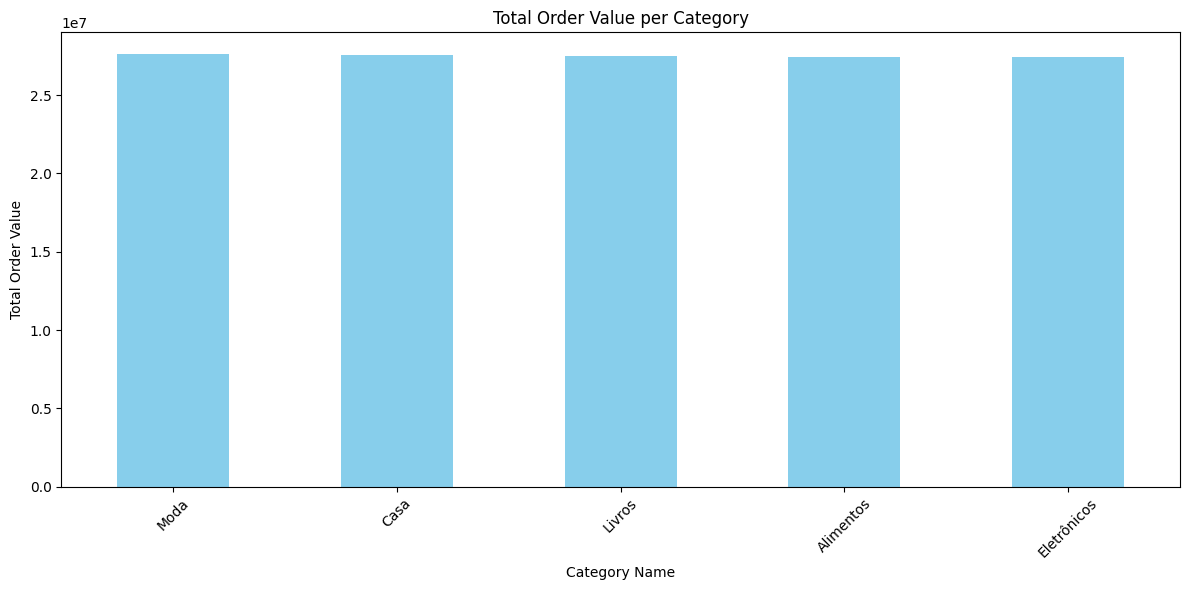

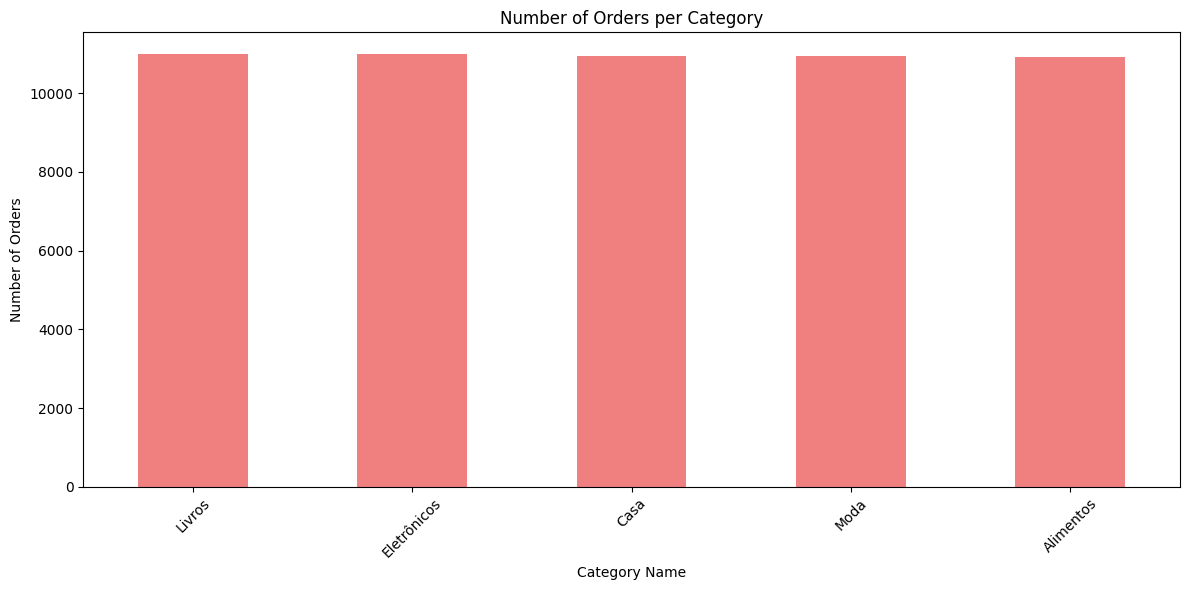

In [9]:
plt.figure(figsize=(12, 6))
category_total_value.plot(kind='bar', color='skyblue')
plt.title('Total Order Value per Category')
plt.xlabel('Category Name')
plt.ylabel('Total Order Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
category_order_count.plot(kind='bar', color='lightcoral')
plt.title('Number of Orders per Category')
plt.xlabel('Category Name')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Customer Demographics

In [10]:
print("Descriptive statistics for CustomerAge:")
print(df['CustomerAge'].describe())

# Define age bins and labels
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']

df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=age_bins, labels=age_labels, right=False)

print("\nDataFrame with AgeGroup column (first 5 rows):")
print(df.head())

Descriptive statistics for CustomerAge:
count    54803.000000
mean        49.210627
std         18.191952
min         18.000000
25%         34.000000
50%         49.000000
75%         65.000000
max         80.000000
Name: CustomerAge, dtype: float64

DataFrame with AgeGroup column (first 5 rows):
   OrderID  CustomerID  CategoryID  OrderValue   OrderDate  CustomerName  \
0        1           1           1      317.06  2024-07-24  Isaac Campos   
1        2           1           4      473.89  2024-04-02  Isaac Campos   
2        3           1           5     4049.82  2024-05-15  Isaac Campos   
3        4           1           5     2923.57  2025-05-04  Isaac Campos   
4        5           1           4     1169.14  2024-07-15  Isaac Campos   

   CustomerAge                City CategoryName AgeGroup  
0           50  Guerra de Mendonça  Eletrônicos    46-55  
1           50  Guerra de Mendonça         Casa    46-55  
2           50  Guerra de Mendonça       Livros    46-55  
3        


Order patterns by Age Group:
          TotalOrderValue  NumberOfOrders
AgeGroup                                 
65+           35572211.76           14081
46-55         22363039.35            8883
36-45         21822678.45            8728
56-65         21812345.77            8638
26-35         20914823.62            8407
18-25         15079598.31            6066

Top 10 Cities by Total Order Value:
City
Peixoto         908401.33
Andrade         874559.94
Garcia          871723.39
da Conceição    864948.16
Cavalcanti      861902.60
Rezende         841107.04
Santos          834246.35
Macedo          833070.12
Caldeira        821717.31
Duarte          811531.14
Name: OrderValue, dtype: float64

Top 10 Cities by Number of Orders:
City
Peixoto         357
Garcia          352
Andrade         350
da Conceição    346
Rezende         341
Santos          333
Cavalcanti      332
Ferreira        331
Caldeira        330
Macedo          330
Name: OrderID, dtype: int64


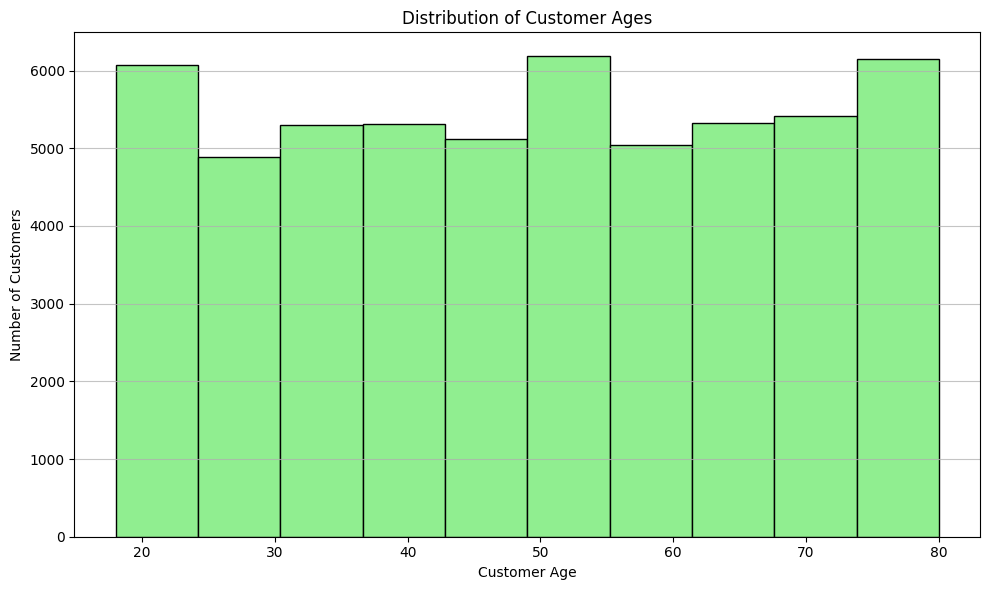

In [12]:
age_group_analysis = df.groupby('AgeGroup', observed=False).agg(TotalOrderValue=('OrderValue', 'sum'), NumberOfOrders=('OrderID', 'count')).sort_values(by='TotalOrderValue', ascending=False)
print("\nOrder patterns by Age Group:")
print(age_group_analysis)

city_order_value = df.groupby('City')['OrderValue'].sum().sort_values(ascending=False)
city_order_count = df.groupby('City')['OrderID'].count().sort_values(ascending=False)

print("\nTop 10 Cities by Total Order Value:")
print(city_order_value.head(10))

print("\nTop 10 Cities by Number of Orders:")
print(city_order_count.head(10))

plt.figure(figsize=(10, 6))
plt.hist(df['CustomerAge'], bins=10, edgecolor='black', color='lightgreen')
plt.title('Distribution of Customer Ages')
plt.xlabel('Customer Age')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

## Sales Trends Over Time



Monthly Sales Trends:
OrderDate
2024-03-31    4056611.00
2024-04-30    5666894.59
2024-05-31    5849381.70
2024-06-30    5479425.72
2024-07-31    5991997.73
2024-08-31    5851606.54
2024-09-30    5722432.49
2024-10-31    6053242.80
2024-11-30    5718522.27
2024-12-31    5850607.16
2025-01-31    6039596.13
2025-02-28    5164507.52
2025-03-31    5881728.00
2025-04-30    5456653.03
2025-05-31    5681689.59
2025-06-30    5895389.88
2025-07-31    5573248.07
2025-08-31    5814873.99
2025-09-30    5904019.63
2025-10-31    6126238.73
2025-11-30    5378342.89
2025-12-31    5902646.20
2026-01-31    5637894.29
2026-02-28    5002268.25
2026-03-31    1864879.06
Freq: ME, Name: OrderValue, dtype: float64


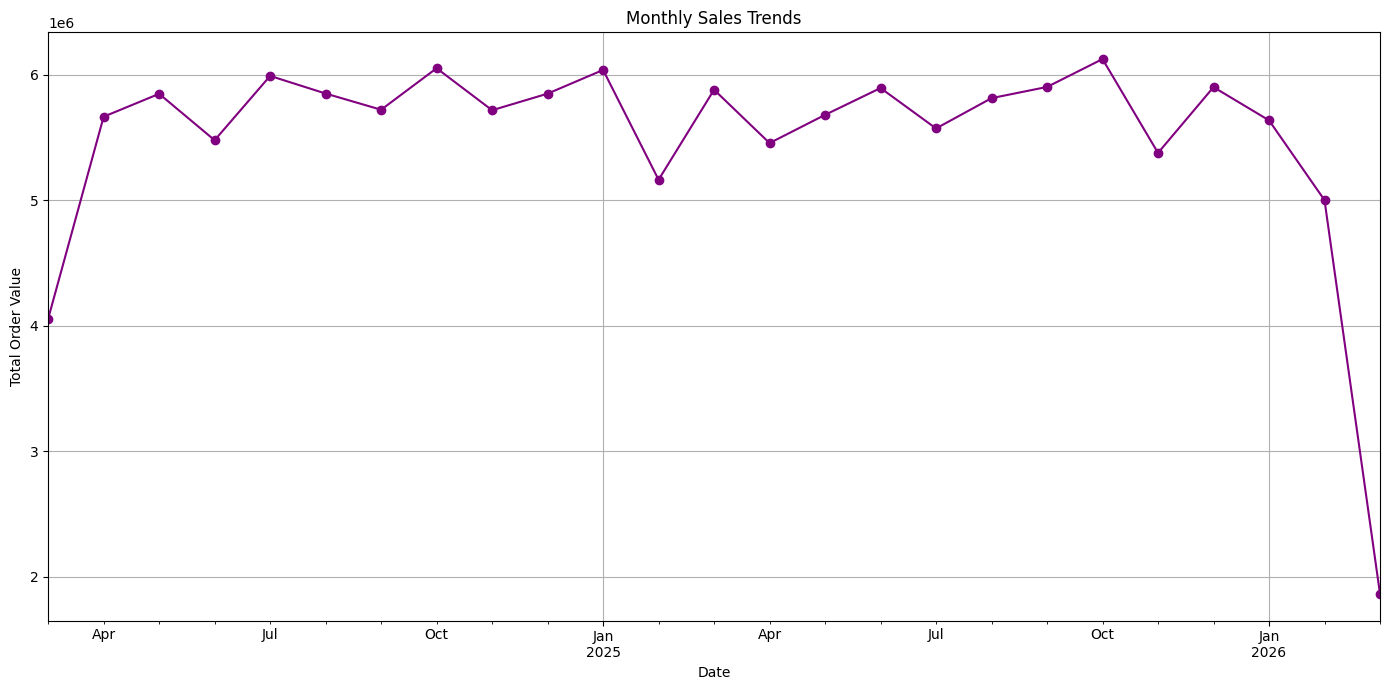

In [15]:
monthly_sales = df['OrderValue'].resample('ME').sum()

print("Monthly Sales Trends:")
print(monthly_sales)

plt.figure(figsize=(14, 7))
monthly_sales.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Sales Trends')
plt.xlabel('Date')
plt.ylabel('Total Order Value')
plt.grid(True)
plt.tight_layout()
plt.show()

# Conclusion of the artificial analysis:
The dataset includes 54,803 order records containing customer, category, and order information, with no missing values after data merging.

Sales performance across categories is relatively balanced. The leading categories by total order value include Moda, Casa, Livros, Alimentos, and Eletrônicos, each generating approximately $27.4–$27.6 million. A similar pattern is observed in order volume, where Livros (10,996 orders) and Eletrônicos (10,987 orders) slightly outperform other categories, though differences remain marginal.

Customer demographics indicate an average age of 49.21 years (range: 18–80). The 65+ age group represents the most significant segment, contributing the highest total order value (approximately $35.57 million) and the largest number of orders (14,081), substantially exceeding younger groups such as the 18–25 segment.

From a geographical perspective, Peixoto, Andrade, and Garcia emerge as the most influential cities in terms of both order value and transaction volume. For example, Peixoto alone accounts for approximately $15.08 million in sales and 6,066 orders.

Finally, monthly sales trends show noticeable variation, ranging from approximately $1.86 million (March 2026) to a peak of $6.13 million (October 2025), suggesting potential seasonal influences on purchasing behavior.

---
# Conclusão da análise artificial:
O conjunto de dados inclui 54.803 registros de pedidos contendo informações de clientes, categorias e pedidos, sem valores ausentes após a mesclagem dos dados.

O desempenho de vendas entre as categorias é relativamente equilibrado. As principais categorias por valor total de pedidos incluem Moda, Casa, Livros, Alimentos e Eletrônicos, cada uma gerando aproximadamente US$ 27,4–US$ 27,6 milhões. Um padrão semelhante é observado no volume de pedidos, onde Livros (10.996 pedidos) e Eletrônicos (10.987 pedidos) apresentam desempenho ligeiramente superior às demais categorias, embora as diferenças permaneçam marginais.

A demografia dos clientes indica uma idade média de 49,21 anos (variação: 18–80 anos). O grupo etário com mais de 65 anos representa o segmento mais significativo, contribuindo com o maior valor total de pedidos (aproximadamente US$ 35,57 milhões) e o maior número de pedidos (14.081), superando substancialmente grupos mais jovens, como o segmento de 18 a 25 anos.

Do ponto de vista geográfico, Peixoto, Andrade e Garcia destacam-se como as cidades mais influentes, tanto em valor de pedidos quanto em volume de transações. Por exemplo, apenas Peixoto é responsável por aproximadamente US$ 15,08 milhões em vendas e 6.066 pedidos.

Finalmente, as tendências mensais de vendas mostram variações notáveis, variando de aproximadamente US$ 1,86 milhão (março de 2026) a um pico de US$ 6,13 milhões (outubro de 2025), sugerindo possíveis influências sazonais no comportamento de compra.